In [1]:
from pathlib import Path
from tqdm import tqdm
import json
tqdm.pandas()
#
import biotite.sequence as seq
import biotite.sequence.io.fasta as fasta
from biotite.sequence.align import Alignment
import biotite.sequence.graphics as graphics
import biotite.structure as struc
import biotite.structure.io as strucio
from atomworks.io.utils.visualize import view
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

Environment variable CCD_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:
  (1) add the line 'export VAR_NAME=path/to/variable' to your .bashrc or .zshrc file
  (2) set it in your current shell with 'export VAR_NAME=path/to/variable'
  (3) write it to a .env file in the root of the atomworks.io repository
Environment variable PDB_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:
  (1) add the line 'export VAR_NAME=path/to/variable' to your .bashrc or .zshrc file
  (2) set it in your current shell with 'export VAR_NAME=path/to/variable'
  (3) write it to a .env file in the root of the atomworks.io repository


#### Sequence diversity of all SolubleMPNN designs

In [34]:
def create_logo(folder, structure_name, start=0, scheme='zappo'):
    # read df of sequences (not incl input)
    df = pd.read_csv(
        f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/{folder}/seqs/seqs.csv'
    )
    df = df[df['id'].str.contains(structure_name)]

    # "align" (stack) sequences
    alignment = Alignment(
        [
            seq.ProteinSequence(s)
            for s in df['sequence']
        ],
        Alignment.trace_from_strings(list(df['sequence']))
    )

    # plot
    profile = seq.SequenceProfile.from_alignment(alignment)
    fig, ax = plt.subplots(figsize=(18, 3))
    graphics.plot_sequence_logo(
        ax,
        profile,
        scheme=scheme
    )
    ax.set_xlabel('residue', fontsize=20, fontweight='bold')
    ax.set_ylabel('bits', fontsize=20, fontweight='bold')
    ax.set_xlim(start, ax.get_xlim()[1])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    fig.tight_layout()
    plt.show()

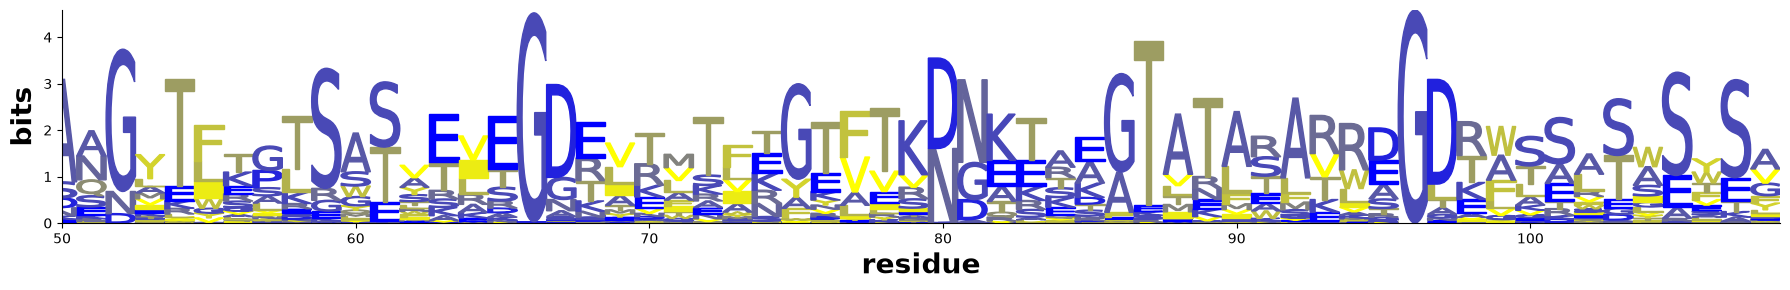

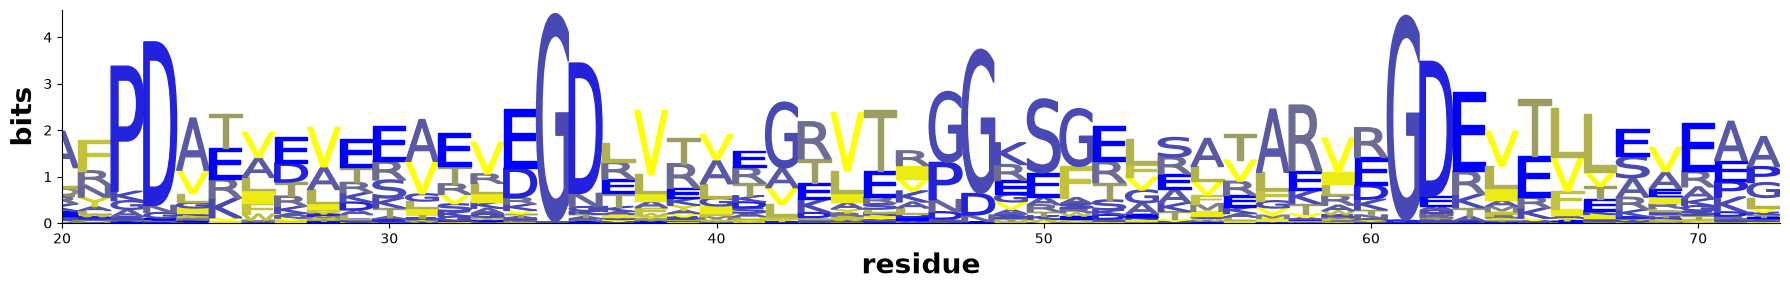

In [32]:
# original, without alanine bias
create_logo('5KPE-5KPH', '5KPE', 50, 'propstrand')
create_logo('5KPE-5KPH', '5KPH', 20, 'propstrand')

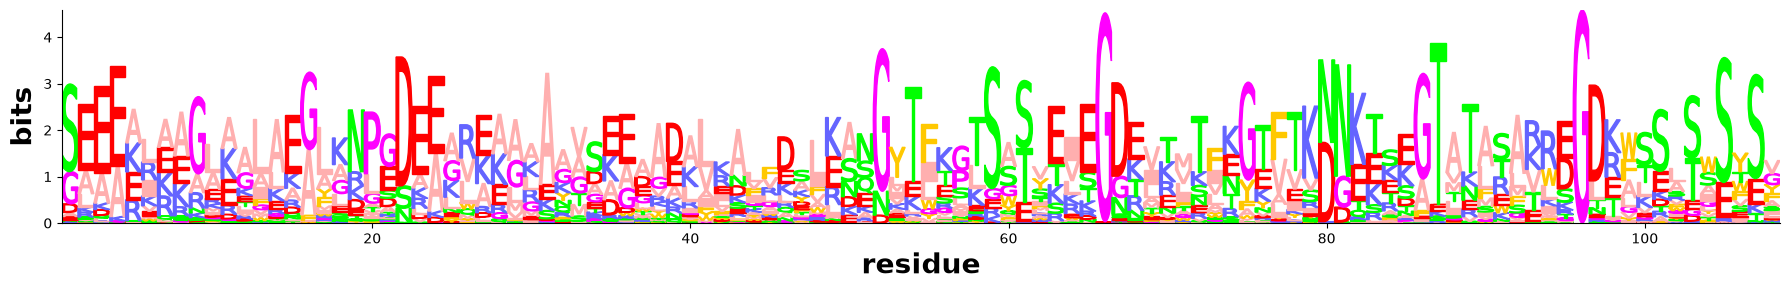

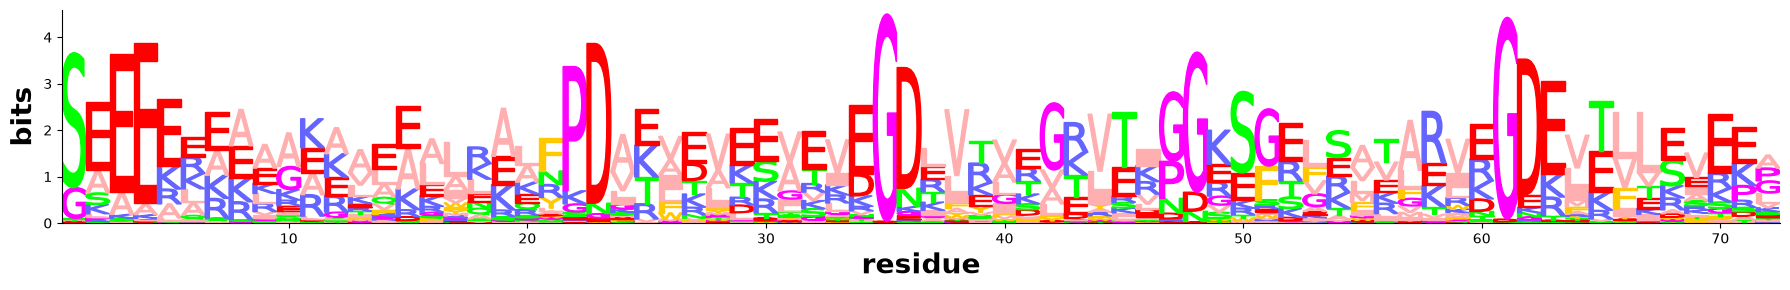

In [15]:
# with alanine bias
create_logo('5KPE-5KPH_bias', '5KPE')
create_logo('5KPE-5KPH_bias', '5KPH')

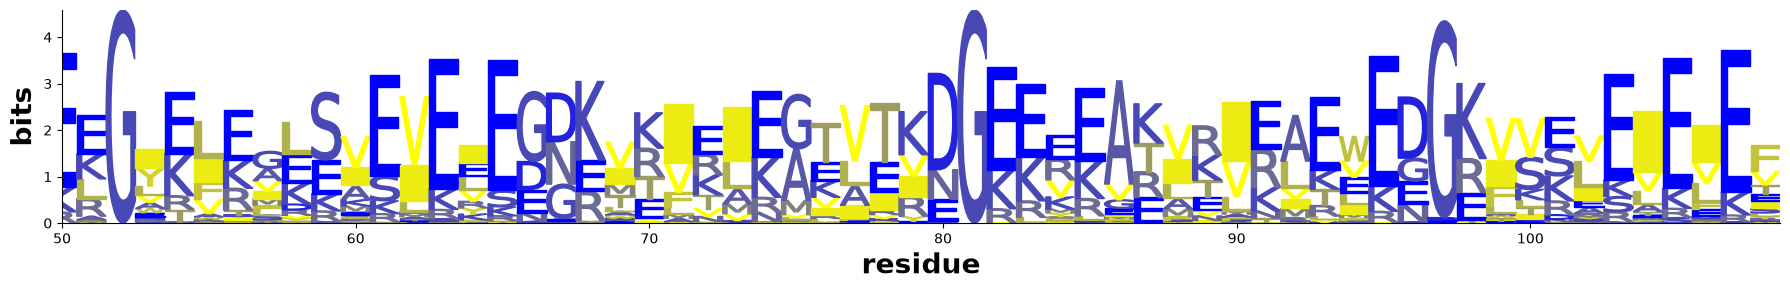

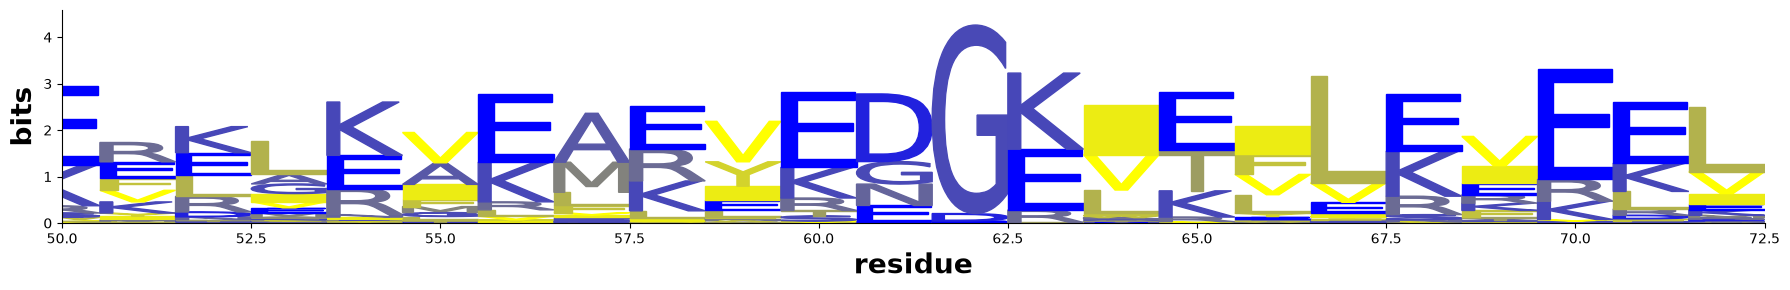

In [33]:
# with rfdiffusion refinement
create_logo('5KPE-5KPH_refined', '5KPE', 50, 'propstrand')
create_logo('5KPE-5KPH_refined', '5KPH', 50, 'propstrand')

### Compile metrics for designs

##### Load scores

In [71]:
# Load scores
nonrefined_df = pd.read_csv('/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH/scores.csv', index_col=0)
#
refined_df = pd.read_csv('/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH_refined/scores.csv', index_col=0)

In [72]:
# Load RMSD scores
def load_rmsd(
    score_dict: dict,
    rmsd_name: str
):
    data = {
        'name': [],
        'rank': [],
        rmsd_name: []
    }
    for input in tqdm(list(score_dict.keys())):
        # Match name
        name = Path(input).name.split('_unrelaxed')[0]
        data['name'].append(name)

        # Match rank
        rank = int(Path(input).name.split('rank_')[1].split('_')[0])
        data['rank'].append(rank)

        # Return rmsd
        data[rmsd_name].append(float(score_dict[input]))
        
    return pd.DataFrame(data)

nonrefined_string_rmsd = '/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH/rmsd_CA_reference_paths.json'
with open(nonrefined_string_rmsd, 'r') as file:
    jsondict = json.load(file)
    score_df = load_rmsd(
        jsondict,
        'rmsd_string'
    )
    nonrefined_df = nonrefined_df.merge(
        score_df,
        on=['name', 'rank'],
        how='left',
        validate = 'one_to_one'
    )

refined_string_rmsd = '/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH_refined/rmsd_CA_reference_paths_string.json'
with open(refined_string_rmsd, 'r') as file:
    jsondict = json.load(file)
    score_df = load_rmsd(
        jsondict,
        'rmsd_string'
    )
    refined_df = refined_df.merge(
        score_df,
        on=['name', 'rank'],
        how='left',
        validate = 'one_to_one'
    )

refined_diffusion_rmsd = '/wynton/home/rotation/geanhu/multi-state/data/colabfold-output/5KPE-5KPH_refined/rmsd_CA_reference_paths_diffusion.json'
with open(refined_diffusion_rmsd, 'r') as file:
    jsondict = json.load(file)
    score_df = load_rmsd(
        jsondict,
        'rmsd_diffusion'
    )
    refined_df = refined_df.merge(
        score_df,
        on=['name', 'rank'],
        how='left',
        validate = 'one_to_one'
    )

100%|██████████████████████████| 12600/12600 [00:00<00:00, 68963.12it/s]


In [73]:
# merge dfs

# rename columns to unique names
nonrefined_df.rename(
    columns={
        'plddt': 'plddt_nonrefined',
        'ptm': 'ptm_nonrefined',
        'rmsd_string': 'rmsd_string_nonrefined'
    },
    inplace = True
)

# fix naming
refined_df['name'] = refined_df['name'].apply(
    lambda name: '_'.join(name.split('_')[:4] + [name.split('_')[-1]])
)

merged_df = refined_df.merge(
    nonrefined_df,
    on=['name', 'rank'],
    how='left',
    validate='one_to_one'
)

In [75]:
# get string sampling parameters back from name
merged_df['rmsd_var'] = merged_df['name'].apply(
    lambda name: int(name.split('_')[1])
)
merged_df['langevin'] = merged_df['name'].apply(
    lambda name: int(name.split('_')[2])
)

In [76]:
# save df
merged_df = merged_df.sort_values(by=['name', 'rank'])
merged_df.to_csv('/wynton/home/rotation/geanhu/multi-state/notebooks/single-state-design.csv')

##### Graph

In [100]:
structure = '5KPH'

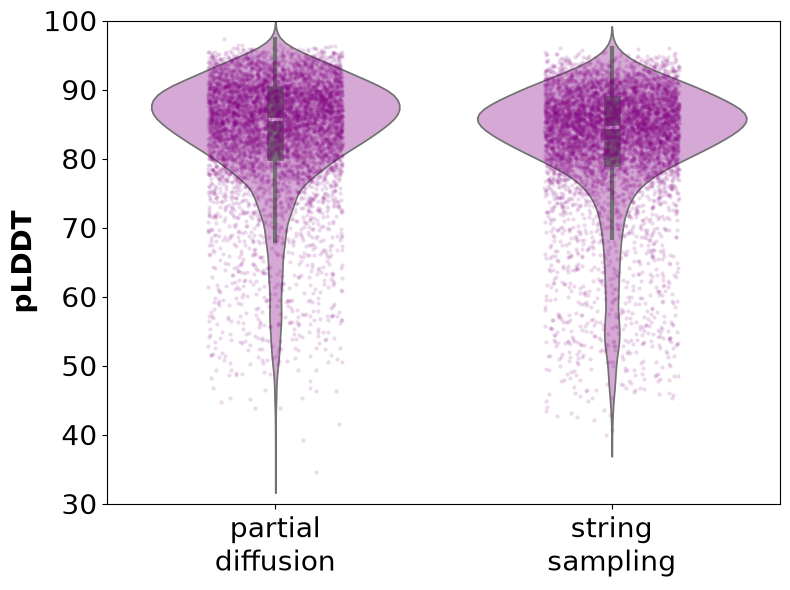

In [107]:
# pooled violin plot
fig, ax = plt.subplots(
    figsize=(8, 6)
)

# organize data
cols = ['plddt', 'plddt_nonrefined'] # CHANGE
graph_df = merged_df[merged_df['name'].str.contains(structure)][cols].melt(
    var_name='group',
    value_name='value'
)

# plot
sns.violinplot(
    data = graph_df,
    x = 'group',
    y = 'value',
    color = 'plum',
    inner = 'box',
    inner_kws={
        'box_width': 12,
        'whis_width': 3
    }
)
sns.stripplot(
    data=graph_df,
    x='group',
    y='value',
    size = 3,
    alpha = 0.15,
    color = 'purple',
    jitter = 0.2
)

# labels
plt.ylabel('pLDDT', fontsize=20, fontweight='bold') #CHANGE
plt.xticks( #CHANGE
    plt.xticks()[0], #type: ignore
    ['partial\ndiffusion', 'string\nsampling']
)
plt.xlabel('')
plt.tick_params('both', labelsize=20)
plt.ylim(30, 100)
plt.tight_layout()
plt.show()

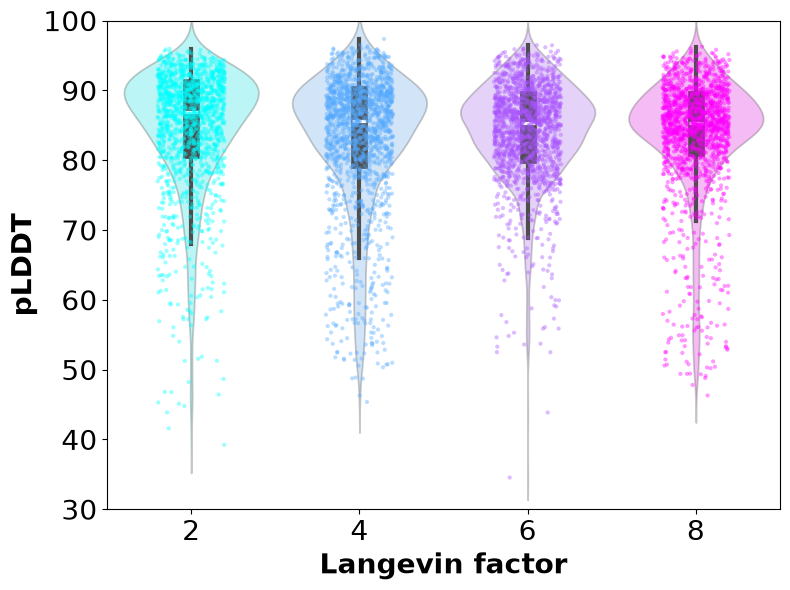

In [109]:
# plot by string sampling parameter
parameter = 'langevin' # 'rmsd_var' 'langevin'
metric = 'plddt' # 'plddt' 'rmsd'

# organize data
graph_df = merged_df[merged_df['name'].str.contains(structure)]

# plot
fig, ax = plt.subplots(
    figsize=(8, 6)
)
sns.violinplot(
    data = graph_df,
    x = parameter,
    y = metric,
    hue = parameter,
    palette = 'cool',
    inner = 'box',
    inner_kws={
        'box_width': 12,
        'whis_width': 3
    },
    legend = False,
    alpha = 0.3
)
sns.stripplot(
    data=graph_df,
    x = parameter,
    y = metric,
    hue = parameter,
    palette = 'cool',
    size = 3,
    alpha = 0.4,
    jitter = 0.2,
    legend = False
)

# labels
#plt.ylabel(r'$C_{\alpha}$ RMSD $\AA$', fontsize=20, fontweight='bold') 
plt.ylabel('pLDDT', fontsize=20, fontweight='bold')
#plt.xlabel(r'sampled alternate state RMSD ($\AA$)', fontsize=20, fontweight='bold')
plt.xlabel('Langevin factor', fontsize=20, fontweight='bold')
plt.tick_params('both', labelsize=20)
#plt.ylim(-2, 30)
plt.ylim(30, 100)
plt.tight_layout()
plt.show()

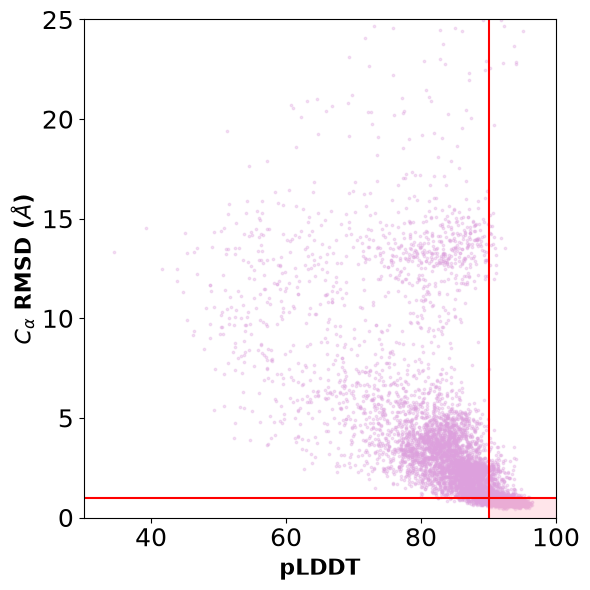

In [112]:
# filtering
plt.figure(figsize=(6, 6))

# scores
graph_df = refined_df[refined_df['name'].str.contains(structure)]
plt.scatter(
    graph_df['plddt'], #change
    graph_df['rmsd_diffusion'], #change
    color = 'plum',
    s = 3,
    alpha = 0.3
)

# cutoffs
plt.axhline(
    y = 1,
    color = 'red'
)
plt.axvline(
    x = 90,
    color = 'red'
)
plt.fill_between(
    [90, 100],
    0, 1,
    facecolor='pink',
    alpha = 0.4
)

# labels
plt.xlabel('pLDDT', fontsize=16, fontweight='bold')
plt.xlim(30, 100)
plt.ylabel(r'$C_{\alpha}$ RMSD ($\AA$)', fontsize=16, fontweight='bold')
plt.ylim(0, 25)
plt.tick_params('both', labelsize=18)
plt.tight_layout()
plt.show()

In [113]:
# print info
df = refined_df[refined_df['name'].str.contains(structure)]

passed = len(df[(df['plddt'] > 90) & (df['rmsd_diffusion'] < 1)])
print(f'{passed} of {len(df)} successful designs')

rate = f'{passed / len(df):.3f}'
print(f'{rate} design success rate')

894 of 6240 successful designs
0.143 design success rate
